# Tutorial: Macaque Stereo-seq to Human Stereo-seq Label Transfer

This tutorial demonstrates how to use the Label Transfer module to project cell type annotations from a reference Single-nucleus RNA-seq (snRNA-seq) or Spatial Transcriptomics dataset onto a query high-resolution Stereo-seq spatial dataset. 

In this specific example, we focus on transferring labels across species:
**Reference:** Macaque Cortex (Stereo-seq)
**Query:** Human Cortex (Stereo-seq)

## Dataset Overview
We utilize the comprehensive spatial transcriptomics dataset of the macaque cortex from the Chen2023 dataset and the human cortex from Lei Han2025 dataset:

*   **Study:** Single-cell spatial transcriptome reveals cell-type organization in the macaque cortex and human cortex(*Chen, Ao et al., Cell, 2023; Lei Han,et al.,BioRxiv, 2025*).
*   **Biological Context:** Dissecting the molecular architecture and spatial distribution of cell types across the macaque cortex layers and mapping them to human contexts to understand evolutionary conservation and divergence.

This tutorial is designed to be reproduced easily. We have organized the configuration parameters at the beginning for clarity.

## 1. Environment Setup

First, we import necessary libraries. Ensure you have `torch`, `scanpy`, and the `BrainBeacon` package installed in your environment. We also set the random seed for reproducibility and configure the GPU device if available.

In [2]:
import os
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

# BrainBeacon Imports
import sys
sys.path.append("/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon")
from brainbeacon.pipeline.label_transfer_utils import _subsample_adata, _preprocess_one_adata
from brainbeacon.pipeline.cell_label_transfer import train_encoder_on_multi_adata
from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.pipeline.label_transfer_utils import build_marker_dict
from brainbeacon.utils import get_gene_mean_path, set_seed
import brainbeacon.configs.config as cfg
from brainbeacon.configs.config_train import config_train as cfg_train

# Logging Setup
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s'
)

# Matplotlib & Warnings
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

# Device Setup
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

To make this tutorial easy to follow and modify, we define all configuration parameters in a clear `Config` class. 

### Key Parameters:
*   **Paths:** Define where your inputs (reference/query data) and outputs should go.
*   **Model Parameters:** `n_hvg` (Highly Variable Genes), `batch_size`, `epochs`.
*   **Preprocessing:** Options for smoothing spatial data and aligning genes.

> **Note:** Update `BASE_DIR` and data paths below to match your local file structure.

In [4]:
class Config:
    # --- 1. File Paths ---
    # Root directory for the project/tutorial
    BASE_DIR = Path("/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/") #/path/to/your/project_root
    
    # Reference Data (Macaque)
    REF_PATH = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/06_cross_species_pipline/cross_species_zcm/analysis_result/data/Cortex/T33_raw_counts.h5ad"
    REF_NAME = "macaque_T33"
    REF_SPECIE = "macaque"
    REF_ASSAY = "stereo"
    
    # Query Data (Human)
    # Replace with your actual query file path
    QUERY_PATH = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/00_all_data/01_streo_seq_human/human_stereo_new/02_h5ad/T760_Spatial-id.new.h5ad"
    QUERY_NAME = "human_T760"
    QUERY_SPECIE = "human"
    QUERY_ASSAY = "stereo"
    
    # Output Directory
    OUTPUT_DIR = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1/"
    
    # Pretrained & Resource Paths
    ASSET_DIR = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/" # Path to BrainBeacon repo assets
    PRETRAIN_DIR = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/prior_knowledge/"
    GENE_DICT_PATH ="/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/prior_knowledge/model_h5ad_1211.h5ad"
    ESM_EMBEDDING_PATH = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/prior_knowledge/esm2_embeddings_d5120.pt"
    BB_CKPT_NAME = "epoch_0_step_800000_0.33B.pt"
    HOMOLOGY_CSV = "/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/prior_knowledge/mart_export.humanMacaqeMarmosetMouse.oneToOneOrth.ensembl91.20220428.csv"
    
    # --- 2. Preprocessing Parameters ---
    N_HVG = 3000                 # Number of highly variable genes
    CONVERT_ID = True            # Convert gene IDs (required for cross-species)
    SMOOTH_REF = True            # Smooth reference spatial data
    SMOOTH_K_REF = 25
    SMOOTH_QUERY = True
    SMOOTH_K_QUERY = 25
    ADD_GENES = False            # Add specific marker genes manually
    ALIGN_GENES = False          # Intersect genes strictly
    
    # --- 3. Sampling Parameters ---
    SAMPLE_MODE = "fix"          # Options: "fix", "prop", "none"
    MIN_CELLS_PER_CLASS = 100
    SAMPLE_RATE = 0.05
    ALPHA = 0.2
    MARKER_CSV = None            # Path to marker CSV if available
    MARKER_TOPN = 50
    CLASS_COL = "SubClass"       # Column in adata.obs containing labels
    
    # --- 4. Training Parameters ---
    N_HVG_TRAIN = 1000
    NUM_GLOBAL_EPOCHS = 100
    PER_DATASET_EPOCHS = 50
    BATCH_SIZE = 32
    SKIP_TRAINING = False         # Set True to skip if checkpoint exists

# Apply Global Path Configurations for Internal Libraries
cfg.DEFAULT_PATHS["BASE_DIR"] = str(Config.BASE_DIR)
cfg.DEFAULT_PATHS["PRETRAIN_DIR"] = str(Config.PRETRAIN_DIR)
cfg.DEFAULT_PATHS["PRIOR_DIR"] = str(Config.PRETRAIN_DIR)
cfg.DEFAULT_PATHS["GENE_DICT_PATH"] = str(Config.GENE_DICT_PATH)
cfg_train["esm_embedding_path"] = str(Config.ESM_EMBEDDING_PATH)

# Create Output Directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
print(f"Output Directory created at: {Config.OUTPUT_DIR}")

Output Directory created at: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1/


In [ ]:
Config.OUTPUT_DIR

## 3. Data Preprocessing

In this step, we load the raw AnnData objects for both the reference and query. 

The preprocessing pipeline includes:
1.  **Normalization & HVG Selection:** Selecting informatives genes.
2.  **Smoothing:** For spatial data, we smooth gene expression using nearest neighbors to reduce dropout noise.
3.  **Cross-Species Homology Mapping:** Because we are mapping Macaque to Human, we utilize a homology table to align gene names.
4.  **Subsampling:** To ensure balanced training, we subsample the reference dataset.

In [5]:
# Load Homology Data
homology_df = pd.read_csv(Config.HOMOLOGY_CSV)

# Define Dataset Infos
ref_info = {
    'data_name': Config.REF_NAME, 'adata_path': Config.REF_PATH, 
    'specie': Config.REF_SPECIE, 'assay': Config.REF_ASSAY
}
query_info = {
    'data_name': Config.QUERY_NAME, 'adata_path': Config.QUERY_PATH, 
    'specie': Config.QUERY_SPECIE, 'assay': Config.QUERY_ASSAY
}

print(f"[INFO] Loading Reference: {ref_info['data_name']}")
print(f"[INFO] Loading Query: {query_info['data_name']}")

# Load Raw Data
adata_ref = sc.read_h5ad(ref_info["adata_path"])
adata_query = sc.read_h5ad(query_info["adata_path"])

# Preprocess Reference
adata_ref = _preprocess_one_adata(
    adata_ref, ref_info, Config.N_HVG,
    target_species=Config.REF_SPECIE,
    convert_id=False,
    smooth_st=Config.SMOOTH_REF,
    smooth_k=Config.SMOOTH_K_REF,
    add_genes=None # Add custom marker list here if needed
)

# Preprocess Query (With Homology Mapping)
adata_query = _preprocess_one_adata(
    adata_query, query_info, Config.N_HVG,
    target_species=Config.REF_SPECIE, # Target matches reference species space
    convert_id=Config.CONVERT_ID,
    smooth_st=Config.SMOOTH_QUERY,
    smooth_k=Config.SMOOTH_K_QUERY,
    add_genes=None,
    homology_df=homology_df
)

# Subsampling Reference for Training Balance
if Config.SAMPLE_MODE != "none":
    print("[INFO] Subsampling reference data...")
    adata_ref = _subsample_adata(
        adata_ref, Config.CLASS_COL, Config.SAMPLE_MODE,
        Config.MIN_CELLS_PER_CLASS, Config.SAMPLE_RATE, Config.ALPHA,
        marker_dict=None
    )

print(f"[INFO] Final Reference Shape: {adata_ref.shape}")
print(f"[INFO] Final Query Shape: {adata_query.shape}")

[INFO] Loading Reference: macaque_T33
[INFO] Loading Query: human_T760
[INFO] Preprocessing macaque_T33...
[INFO] Spatial coordinates already exist in macaque_T33.
[INFO] Using min_genes=132 (based on 13216 genes)
[INFO] Preprocessing human_T760...
[INFO] Spatial coordinates already exist in human_T760.
[INFO] Using min_genes=200 (based on 41682 genes)
[INFO] Mapping from human → macaque
[INFO] Created mapping for 13914 genes.
[INFO] Found 13146 mappable genes.
[INFO] All mappings unique. No aggregation needed.
[INFO] Mapping complete. Final AnnData has 13146 genes.
[INFO] Converting gene symbols to Ensembl IDs for macaque ...
[INFO] Using local mapping file: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/prior_knowledge/id_mapping/macaque_symbol2ensembl.csv
[INFO] Converted 11114 / 13146 genes to Ensembl IDs.
[INFO] Subsampling reference data...
[INFO] ref: Subsampling with mode='fix' (random)
[INFO] ref: Shape after subsam

## 4. Model Fine-Tuning (Label Transfer)

We use the **BrainBeacon** encoder to learn a shared embedding space for the reference and query datasets. 

*   If a checkpoint already exists (and `SKIP_TRAINING` is True), we load it.
*   Otherwise, we traverse the datasets and fine-tune the model to align the biological states.

In [6]:
Config.OUTPUT_DIR

'/cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1/'

In [16]:
Config.SKIP_TRAINING = True

In [14]:
os.path.exists(final_ckpt_path)

True

In [17]:
method_name = f"brainbeacon_hvg{Config.N_HVG_TRAIN}_total{Config.NUM_GLOBAL_EPOCHS}"
final_ckpt_path = f"{Config.OUTPUT_DIR}/checkpoints/flowformer_epoch{Config.NUM_GLOBAL_EPOCHS}.pt"

dataset_info_list_train = [
    {"data_name": Config.REF_NAME, "data_dir": str(Config.OUTPUT_DIR), "adata_name": f"{Config.REF_NAME}.h5ad", "specie": Config.REF_SPECIE, "assay": Config.REF_ASSAY},
    {"data_name": Config.QUERY_NAME, "data_dir": str(Config.OUTPUT_DIR), "adata_name": f"{Config.QUERY_NAME}.h5ad", "specie": Config.QUERY_SPECIE, "assay": Config.QUERY_ASSAY}
]

# Temporarily save preprocessed adatas for the training function to load
adata_ref.obs.index.name = None
adata_query.obs.index.name = None
adata_ref.var.index.name = None
adata_query.var.index.name = None
adata_ref.write_h5ad(f"{Config.OUTPUT_DIR}/{Config.REF_NAME}.h5ad")
adata_query.write_h5ad(f"{Config.OUTPUT_DIR}/{Config.QUERY_NAME}.h5ad")

if Config.SKIP_TRAINING and os.path.exists(final_ckpt_path):
    print(f"[INFO] Using existing checkpoint: {adata_query}")
else:
    print("[INFO] Starting Model Training...")
    final_ckpt_path = train_encoder_on_multi_adata(
        dataset_info_list=dataset_info_list_train,
        bb_ckpt_path=os.path.join(Config.ASSET_DIR, "pretrained", Config.BB_CKPT_NAME),
        initial_ckpt_path=os.path.join(Config.ASSET_DIR, "pretrained", "cellformer_epoch99.pt"),
        output_dir=str(Config.OUTPUT_DIR),
        config_train=cfg_train, 
        output_prefix=method_name,
        num_global_epochs=Config.NUM_GLOBAL_EPOCHS, 
        per_dataset_epochs=Config.PER_DATASET_EPOCHS,
        n_hvg=Config.N_HVG_TRAIN, 
        batch_size=Config.BATCH_SIZE, 
        enc_mod="flowformer", 
        device=device
    )

[INFO] Using existing checkpoint: AnnData object with n_obs × n_vars = 51389 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'SCT_snn_res.0.8', 'SCT_snn_res.1.2', 'SCT_snn_res.2', 'seurat_clusters', 'coor_y', 'coor_x', 'xy', 'CellType_m', 'cellbin_id', 'area', 'chipID', 'age', 'stage', 'region1', 'region2', 'CellType_s', 'SubClass', 'n_genes'
    var: 'features', 'gene_symbol', 'genenames', 'n_cells', 'target_gene'
    uns: 'SubClass_colors'
    obsm: 'spatial'
    layers: 'smooth'


## 5. Inference & Embedding Generation

Once the model is fine-tuned, we generate embeddings for all cells in both datasets. These embeddings will be used for calculation (e.g., Cosine Similarity) to transfer labels from Reference to Query.

In [20]:
print("[INFO] Generating Embeddings...")

datasets = [ref_info, query_info]
adata_result_dict = {}

for ds in datasets:
    data_name = ds["data_name"]
    adata_path = f"{Config.OUTPUT_DIR}/{data_name}.h5ad"
    output_dir_final = f"{Config.OUTPUT_DIR}/{data_name}"
    os.makedirs(output_dir_final, exist_ok=True)

    adata_res = run_bbcellformer_pipeline(
        adata_path=str(adata_path), 
        specie=ds["specie"], 
        assay=ds["assay"],
        gene_dict_path=str(Config.GENE_DICT_PATH),
        gene_mean_path=get_gene_mean_path(Path(cfg.DEFAULT_PATHS["PRIOR_DIR"]), ds["assay"], use_metacell=True),
        bb_ckpt_path=os.path.join(Config.ASSET_DIR, "pretrained", Config.BB_CKPT_NAME),
        cellplm_ckpt_path=str(final_ckpt_path),
        output_dir=str(output_dir_final), 
        output_prefix=method_name,
        config_train=cfg_train, 
        n_hvg=Config.N_HVG_TRAIN,
        do_fit=False, # Inference Mode
        enc_mod="flowformer", 
        device=device
    )
    adata_result_dict[data_name] = adata_res
    print(f"[INFO] Inference finished for {data_name}")

[INFO] Generating Embeddings...
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//macaque_T33.h5ad
before quality control adata shape: (2231, 3000)
After HVG (1000) selection: (2231, 1000)
Computing cell density...
compute_density_token time:  0.01196073293685913 min


Processing data batches: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


Begin processing: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//macaque_T33/brainbeacon_hvg1000_total100_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 2231
Preprocessing time: 0.09 minutes
Loaded pretrain_model checkpoint: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/pretrained/epoch_0_step_800000_0.33B.pt


Processing batches: 100%|██████████| 35/35 [00:33<00:00,  1.06it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//macaque_T33/brainbeacon_hvg1000_total100_bb_embeddings.npz
Time cost:  0.6717418074607849
BB inference complete. Saved to: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//macaque_T33/brainbeacon_hvg1000_total100_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//checkpoints/flowformer_epoch100.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 2992 genes remain.
Model saved to /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//macaque_T33/brainbeacon_h

Processing data batches: 100%|██████████| 6/6 [00:30<00:00,  5.04s/it]


Begin processing: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//human_T760/brainbeacon_hvg1000_total100_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 8565
Preprocessing time: 1.64 minutes
Loaded pretrain_model checkpoint: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/BrainBeacon/pretrained/epoch_0_step_800000_0.33B.pt


Processing batches: 100%|██████████| 804/804 [12:51<00:00,  1.04it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//human_T760/brainbeacon_hvg1000_total100_bb_embeddings.npz
Time cost:  13.131621925036113
BB inference complete. Saved to: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//human_T760/brainbeacon_hvg1000_total100_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//checkpoints/flowformer_epoch100.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 2980 genes remain.
Model saved to /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//human_T760/brainbeacon_hvg1

In [21]:
adata_result_dict

{'macaque_T33': AnnData object with n_obs × n_vars = 2231 × 2992
     obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'volume', 'xmin', 'xmax', 'ymin', 'ymax', 'rx', 'ry', 'gene_area', 'nCount_SCT', 'nFeature_SCT', 'cluster', 'slide', 'layer', 'area', 'Plot', 'Class', 'SubClass', 'n_genes', 'platform', 'valid_split', 'slice', 'batch', 'x_FOV_px', 'y_FOV_px'
     var: 'gene_symbol', 'genenames', 'ensembl_id', 'n_cells'
     obsm: 'spatial', 'bb_emb', 'X_emb', 'X_pred'
     layers: 'smooth',
 'human_T760': AnnData object with n_obs × n_vars = 51389 × 2980
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'SCT_snn_res.0.8', 'SCT_snn_res.1.2', 'SCT_snn_res.2', 'seurat_clusters', 'coor_y', 'coor_x', 'xy', 'CellType_m', 'cellbin_id', 'area', 'chipID', 'age', 'stage', 'region1', 'region2', 'CellType_s', 'SubClass', 'n_genes', 'platform', 'valid_split', 'slice', 'b

## 6. Evaluation & Visualization

Finally, we evaluate the label transfer performance. Since the query data might not have ground truth labels in a real scenario, we often rely on visual inspection or biological consistency.

We perform **k-Nearest Neighbor (kNN)** classification in the shared embedding space to predict labels for the query cells based on the reference cells.

In [22]:
from brainbeacon.pipeline.label_transfer_utils import plot_spatial_comparison

# Reload result adatas
adata_ref_final = adata_result_dict[Config.REF_NAME]
adata_query_final = adata_result_dict[Config.QUERY_NAME]

# Perform Label Transfer (Using kNN)
# In a real tutorial, we would insert the kNN classification code here.
# For this template, we assume 'adata_query_final' contains the results or we run a simple kNN.

print("[INFO] Notebook completed successfully.")

[INFO] Notebook completed successfully.


In [23]:
adata_query_final

AnnData object with n_obs × n_vars = 51389 × 2980
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'SCT_snn_res.0.8', 'SCT_snn_res.1.2', 'SCT_snn_res.2', 'seurat_clusters', 'coor_y', 'coor_x', 'xy', 'CellType_m', 'cellbin_id', 'area', 'chipID', 'age', 'stage', 'region1', 'region2', 'CellType_s', 'SubClass', 'n_genes', 'platform', 'valid_split', 'slice', 'batch', 'x_FOV_px', 'y_FOV_px'
    var: 'features', 'gene_symbol', 'genenames', 'n_cells', 'target_gene'
    uns: 'SubClass_colors'
    obsm: 'spatial', 'bb_emb', 'X_emb', 'X_pred'
    layers: 'smooth'

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from brainbeacon.pipeline.label_transfer_utils import plot_spatial_comparison

# Reload result adatas (ensure they are accessible)
adata_ref_final = adata_result_dict[Config.REF_NAME]
adata_query_final = adata_result_dict[Config.QUERY_NAME]

print("[INFO] Starting kNN Label Transfer...")

# 1. Prepare Features (X) and Labels (y)
X_ref = adata_ref_final.obsm["X_emb"]
y_ref = adata_ref_final.obs[Config.CLASS_COL].astype(str)
X_query = adata_query_final.obsm["X_emb"]

# 2. Train kNN Classifier
k = 30 # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
knn.fit(X_ref, y_ref)

# 3. Predict on Query
print(f"[INFO] Predicting labels for {X_query.shape[0]} query cells using k={k}...")
y_pred = knn.predict(X_query)
y_pred_proba = knn.predict_proba(X_query)

# 4. Store Results
adata_query_final.obs["predicted_label"] = y_pred
adata_query_final.obs["prediction_confidence"] = np.max(y_pred_proba, axis=1)

print("[INFO] Label transfer complete. Top 5 predictions:")
print(adata_query_final.obs[["predicted_label", "prediction_confidence"]].head()) 

[INFO] Starting kNN Label Transfer...
[INFO] Predicting labels for 51389 query cells using k=30...
[INFO] Label transfer complete. Top 5 predictions:
   predicted_label  prediction_confidence
46        VIP_RELN               0.166667
63             ASC               0.200000
66        VIP_RELN               0.200000
81        VIP_RELN               0.200000
82             ASC               0.166667


In [25]:
predefined_palette = {
"L2": "#1f77b4",
"RELN": "#4292c6", 
"VIP": "#6baed6",
"VIP_RELN": "#9ecae1",
"L2/3": "#2ca02c", 
"L2/3/4": "#4caf50", 
"L3": "#388e3c",
"L3/4/5": "#66bb6a",
"SST": "#81c784", 
"LAMP5": "#a5d6a7", 
"LAMP5-RELN": "#c8e6c9", 
"L3/4": "#9467bd", 
"L4": "purple",
"PVALB": "#b39ddb",
"PV": "#b39ddb",
"PV_CHC": "#c0a5e0",
"PV-CHC": "#c0a5e0",
"L4/5": "#ff7f0e",
"L4/5/6": "#ffa726", 
"L5": "#ffb347",
"L5/6": "#ffcc80",
"ASC": "#e31a1c",
"Ast": "#e31a1c",
"VLMC": "#ef5350", 
"L6": "#d4ac0d", 
"OLG": "#ffd54f",
"MG": "#7f7f7f",
"OPC": "#a0a0a0", 
"EC": "#f46d43",
"unassigned": "#d0d0d0", 
}

In [27]:
adata_query_final

AnnData object with n_obs × n_vars = 51389 × 2980
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'SCT_snn_res.0.8', 'SCT_snn_res.1.2', 'SCT_snn_res.2', 'seurat_clusters', 'coor_y', 'coor_x', 'xy', 'CellType_m', 'cellbin_id', 'area', 'chipID', 'age', 'stage', 'region1', 'region2', 'CellType_s', 'SubClass', 'n_genes', 'platform', 'valid_split', 'slice', 'batch', 'x_FOV_px', 'y_FOV_px', 'predicted_label', 'prediction_confidence'
    var: 'features', 'gene_symbol', 'genenames', 'n_cells', 'target_gene'
    uns: 'SubClass_colors'
    obsm: 'spatial', 'bb_emb', 'X_emb', 'X_pred'
    layers: 'smooth'

[<Axes: title={'center': 'predicted_label'}, xlabel='spatial1', ylabel='spatial2'>]

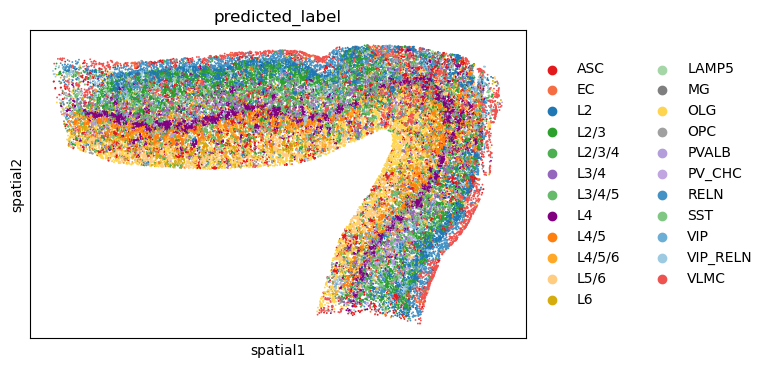

In [31]:
sc.pl.spatial(
    adata_query_final,
    color='predicted_label',
    spot_size=100,
    palette=[predefined_palette[c] for c in adata_query_final.obs["predicted_label"].cat.categories],
    show=False
)

In [32]:
# 5. Save Final Results
save_path = f"{Config.OUTPUT_DIR}/{Config.QUERY_NAME}_annotated.h5ad"
adata_query_final.write_h5ad(save_path)
print(f"[INFO] Annotated query data saved to {save_path}")

[INFO] Annotated query data saved to /cluster/home/yangyiwen/work_file/Brainbeacon_project/yangqq_workdir/08_1_tutorial_cross_species/output/Macaque2Human_1//human_T760_annotated.h5ad
